In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import transforms
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


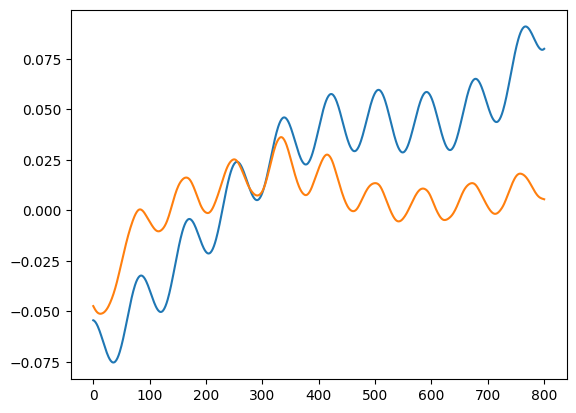

In [50]:
E_df = pd.read_csv('/content/drive/MyDrive/SML Final Project/efield.csv')
I_df = pd.read_csv('/content/drive/MyDrive/SML Final Project/current_splined.csv')
E_all = E_df.to_numpy()[:,1:]
I_all = I_df.to_numpy()[:,1:]

E_train = E_all[:,:70]
E_val = E_all[:,70:85]
E_test = E_all[:,85:]

I_train = I_all[:,:70]
I_val = I_all[:,70:85]
I_test = I_all[:,85:]

plt.plot(E_all[:,6])
plt.plot(I_all[:,6])

In [103]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [119]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.branch_net = nn.Sequential(
        nn.Linear(801, 256).double(),
        nn.Tanh(),
        nn.Linear(256, 256).double(),
        nn.Tanh(),
        nn.Linear(256, 256).double()
    ).double()

    self.trunk_net = nn.Sequential(
        nn.Linear(1, 64).double(),
        nn.Tanh(),
        nn.Linear(64, 64).double(),
        nn.Tanh(),
        nn.Linear(64, 256).double()
    ).double()

  def forward(self, E, t):
    R = torch.matmul(self.branch_net(E), self.trunk_net(t))
    return R

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (branch_net): Sequential(
    (0): Linear(in_features=801, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
  )
  (trunk_net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=256, bias=True)
  )
)


In [120]:
learning_rate = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

N_traj = 70 # number of trajectories
N_step = 801 # number of steps in each trajectory

In [121]:
epochs = 10000
validation_loss = np.zeros(30)
total_loss = np.zeros(epochs*3)

for i in range(epochs):
  model.train()
  Es = torch.from_numpy(E_all).to(device)
  Ts = torch.from_numpy(np.linspace(-1, 1, 801)).to(device)
  Is = torch.from_numpy(I_all).to(device)
  Step = np.random.randint(0, 70*801-1)
  time = Step % 801
  traj = int(Step/801)
  E = Es[:,traj]
  I = Is[:,traj]
  R_true = 10*(I - E)
  step=int(time)
  Rj = R_true[step]
  t = Ts[step][None]
  pred = model(E, t)
  loss = loss_fn(pred, Rj)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  cycle_loss = loss
  total_loss[i] = loss.detach().to('cpu').numpy()
  # Compute Validation Loss
  if i%1000 == 0:
    model.eval()
    val_cycle_loss = 0
    for k in range(15):
      E = Es[:,k+70]
      I = Is[:,k+70]
      R_true = 10*(I - E)
      for step in range(801):
        t = Ts[step][None]
        Rj = R_true[step]
        pred = model(E, t)
        loss = loss_fn(pred, Rj)
        val_cycle_loss += loss
    print(val_cycle_loss)
    validation_loss[int(i/1000)] = val_cycle_loss.detach().to('cpu').numpy()


    print(f'Epoch {i} complete, cycle loss: {cycle_loss}')
learning_rate = 0.0002
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
for i in range(epochs):
  model.train()
  Es = torch.from_numpy(E_all).to(device)
  Ts = torch.from_numpy(np.linspace(-1, 1, 801)).to(device)
  Is = torch.from_numpy(I_all).to(device)
  Step = np.random.randint(0, 70*801-1)
  time = Step % 801
  traj = int(Step/801)
  E = Es[:,traj]
  I = Is[:,traj]
  R_true = 10*(I - E)
  step=int(time)
  Rj = R_true[step]
  t = Ts[step][None]
  pred = model(E, t)
  loss = loss_fn(pred, Rj)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  cycle_loss = loss
  total_loss[10000+i] = loss.detach().to('cpu').numpy()
  # Compute Validation Loss
  if i%1000 == 0:
    model.eval()
    val_cycle_loss = 0
    for k in range(15):
      E = Es[:,k+70]
      I = Is[:,k+70]
      R_true = 10*(I - E)
      for step in range(801):
        t = Ts[step][None]
        Rj = R_true[step]
        pred = model(E, t)
        loss = loss_fn(pred, Rj)
        val_cycle_loss += loss
    print(val_cycle_loss)
    validation_loss[10+int(i/1000)] = val_cycle_loss.detach().to('cpu').numpy()


    print(f'Epoch {i} complete, cycle loss: {cycle_loss}')
learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
for i in range(epochs):
  model.train()
  Es = torch.from_numpy(E_all).to(device)
  Ts = torch.from_numpy(np.linspace(-1, 1, 801)).to(device)
  Is = torch.from_numpy(I_all).to(device)
  Step = np.random.randint(0, 70*801-1)
  time = Step % 801
  traj = int(Step/801)
  E = Es[:,traj]
  I = Is[:,traj]
  R_true = 10*(I - E)
  step=int(time)
  Rj = R_true[step]
  t = Ts[step][None]
  pred = model(E, t)
  loss = loss_fn(pred, Rj)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  cycle_loss = loss
  total_loss[20000+i] = loss.detach().to('cpu').numpy()
  # Compute Validation Loss
  if i%1000 == 0:
    model.eval()
    val_cycle_loss = 0
    for k in range(15):
      E = Es[:,k+70]
      I = Is[:,k+70]
      R_true = 10*(I - E)
      for step in range(801):
        t = Ts[step][None]
        Rj = R_true[step]
        pred = model(E, t)
        loss = loss_fn(pred, Rj)
        val_cycle_loss += loss
    print(val_cycle_loss)
    validation_loss[20+int(i/1000)] = val_cycle_loss.detach().to('cpu').numpy()


    print(f'Epoch {i} complete, cycle loss: {cycle_loss}')

tensor(2547.4197, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 0 complete, cycle loss: 0.26982749650216187
tensor(590.8441, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 1000 complete, cycle loss: 0.014022781007545032
tensor(426.4345, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 2000 complete, cycle loss: 0.09715559535707212
tensor(560.2576, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 3000 complete, cycle loss: 0.0062383430649784796
tensor(566.6992, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 4000 complete, cycle loss: 0.0015852258897204917
tensor(438.0058, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 5000 complete, cycle loss: 0.019186222395613507
tensor(403.3161, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 6000 complete, cycle loss: 0.027555840414078367
tensor(342.2884, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 7000 complete, cycle loss: 0.05390839056875427
tensor(277.0541, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch 8000 co

Text(0.5, 0, 'Training Cycle')

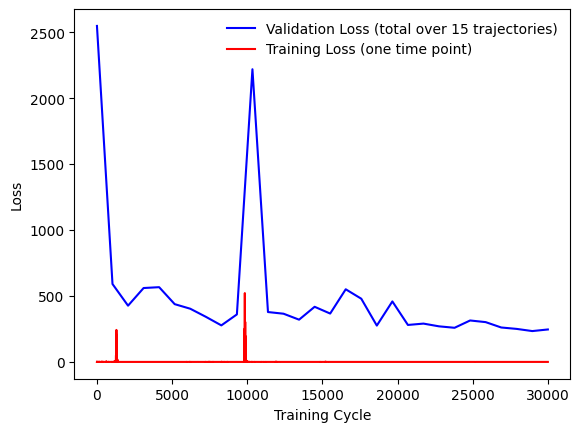

In [226]:
plt.plot(np.linspace(0, 30000, 30), validation_loss, color='blue', label='Validation Loss (total over 15 trajectories)')
plt.plot(np.linspace(0, 30000, 30000), total_loss, color='red', label='Training Loss (one time point)')
plt.legend(frameon=False)
plt.ylabel('Loss')
plt.xlabel('Training Cycle')

In [207]:
i_check =97
E_check = E_all[:,i_check]
I_check = np.zeros_like(E_check)

In [208]:
E_check = E_all[:,i_check]
R_check = np.zeros_like(E_check)
model.eval()
ts = np.linspace(-1, 1, 801)
E_check = torch.from_numpy(E_check)
ts = torch.from_numpy(ts)
for i, e in enumerate(E_check):
  inter = model(E_check, ts[i][None])
  R_check[i] = inter.detach().to('cpu').numpy()

/tmp/ipykernel_462/3046177892.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(E_check+0.1*R_check, label=r'$I_\text{pred}$', color='blue')


Text(0, 0.5, 'Normalized Current or Electric Field')

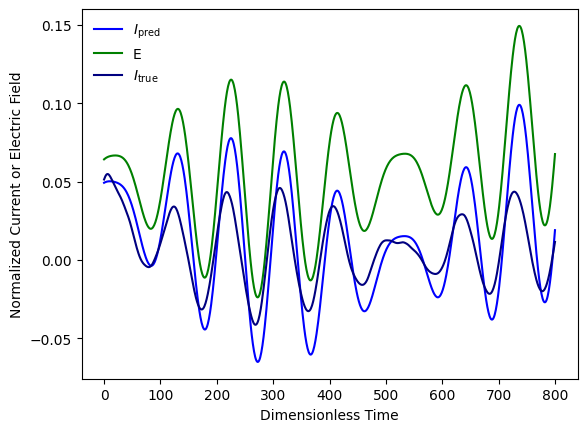

In [209]:
plt.plot(E_check+0.1*R_check, label=r'$I_\text{pred}$', color='blue')
plt.plot(E_check, label=r'E', color='green')
plt.plot(I_all[:,i_check], label=r'$I_\text{true}$', color='navy')
plt.legend(frameon=False)
plt.xlabel('Dimensionless Time')
plt.ylabel('Normalized Current or Electric Field')

In [ ]:
np.mean(I_all[:,1]-E_all[:,1])

np.float64(-0.0009135038751675063)

In [41]:
int(9.6)

9

In [218]:
# Final Evaluation on Test Data

model.eval()
test_loss = np.zeros(15)
for k in range(15):
  val_cycle_loss = 0
  E = Es[:,k+85]
  I = Is[:,k+85]
  R_true = 10*(I - E)
  for step in range(801):
    t = Ts[step][None]
    Rj = R_true[step]
    pred = model(E, t)
    loss = loss_fn(pred, Rj)
    val_cycle_loss += loss
  print(val_cycle_loss)
  test_loss[k] = val_cycle_loss.detach().to('cpu').numpy()

tensor(27.0586, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(45.4517, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(16.8238, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(14.0506, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(43.8758, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(28.1157, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(24.4776, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(17.5524, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(11.8869, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(24.4249, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(41.8350, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(42.9555, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(37.0745, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(31.0370, dtype=torch.float64, grad_fn=<AddBackward0>)
tensor(38.1471, dtype=torch.float64, grad_fn=<AddBackward0>)


In [220]:
np.sum(test_loss)

np.float64(444.7670107203269)

In [221]:
np.mean(test_loss)

np.float64(29.65113404802179)

In [223]:
np.std(test_loss)

np.float64(11.074553438054188)